# SAM2 Segmentation Workflow

**Steps:**
1. **Configure** — set `SPK` and verify paths  
2. **Select init frame** — browse a speaker video and save the reference JPEG  
3. **Load models** — SAM2 image predictor (prompting) + video predictor (propagation)  
4. **Define regions** — edit `REGION_DEFS` with the anatomical regions to track  
5. **Prompt regions** — interactively click positive/negative points on the init frame  
6. **Test propagation** — run on a random 200-frame window; view overlay inline  
7. **Export** — write `session.json` to `sam_seg/` for use with `sam2_propagate.py`  

> **Requires** `ipympl` for interactive prompting: `pip install ipympl`

# Server Config 

1. Create server port with jupyter in tmux

```
jupyter notebook --no-browser --port=8888
```

2. Locally, create server tunnel for using GPU

```
alias gpu-tunnel="ssh -N -L 8888:localhost:8888 user@your-gpu-server.com"
```

In future runs, one can run: 

```
gpu-tunnel
```

Always need two terminals running each of these steps. 

In the notebook, add the url for the port as a new kernel. It should save and can be accessed using localhost in the future. 

In [29]:
import os, sys, json

# ── Edit these two lines ────────────────────────────────────────────────
SPK      = 'spk1'
REPO_DIR = '/data1/span_data/sam2'
# ───────────────────────────────────────────────────────────────────────

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

with open(os.path.join(REPO_DIR, 'sam2_config.json')) as _f:
    _cfg = json.load(_f)

DATA_DIR     = _cfg['data_dir']
VIDEO_SUBDIR = _cfg.get('video_subdir')
CHECKPOINT   = os.path.join(REPO_DIR, _cfg.get('checkpoint', 'checkpoints/sam2.1_hiera_large.pt'))
MODEL_CFG    = _cfg.get('model_cfg', 'configs/sam2.1/sam2.1_hiera_l.yaml')
DEVICE_STR   = _cfg.get('device', 'cuda')

VIDEO_DIR   = os.path.join(DATA_DIR, SPK, *VIDEO_SUBDIR.split('/'))
SAM_SEG_DIR = os.path.join(DATA_DIR, SPK, 'sam_seg')
os.makedirs(SAM_SEG_DIR, exist_ok=True)

print(f'Speaker  : {SPK}')
print(f'Videos   : {VIDEO_DIR}')
print(f'Output   : {SAM_SEG_DIR}')
print(f'Device   : {DEVICE_STR}')

Speaker  : spk1
Videos   : /data1/span_data/gloss/spk1/post/video
Output   : /data1/span_data/gloss/spk1/sam_seg
Device   : cuda


In [2]:
!pip install ipympl

In [3]:
import os, json, shutil, random, tempfile
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import numpy as np
import torch
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import HBox, Label, Dropdown, ToggleButtons, Button
import cv2
from PIL import Image, ImageDraw
from IPython.display import display, Video

%matplotlib widget

device = torch.device(
    DEVICE_STR
    if DEVICE_STR == 'cpu' or (DEVICE_STR.startswith('cuda') and torch.cuda.is_available())
    else 'cpu'
)
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(device)}')

Using device: cuda
  GPU: NVIDIA RTX 6000 Ada Generation


In [4]:
from sam2.build_sam import build_sam2, build_sam2_video_predictor
from sam2.sam2_image_predictor import SAM2ImagePredictor

print('Loading SAM2 models...')
_sam2_base    = build_sam2(MODEL_CFG, CHECKPOINT, device=device)
img_predictor = SAM2ImagePredictor(_sam2_base)

vid_predictor = build_sam2_video_predictor(MODEL_CFG, CHECKPOINT, device=device)
print('Done.')

Loading SAM2 models...
Done.


## 1 — Select & Save Init Frame

Use the dropdown to pick a video, drag the slider to the desired frame, then click **Save as init frame**.

In [30]:
video_files = sorted(f for f in os.listdir(VIDEO_DIR) if f.lower().endswith('.avi'))
if not video_files:
    raise FileNotFoundError(f'No .avi files found in {VIDEO_DIR}')
print(f'{len(video_files)} video(s) found.')

ann_frame_idx   = 0
INIT_FRAME_PATH = os.path.join(SAM_SEG_DIR, f'{SPK}_frame_post.jpg')

_cap    = [None]
_nf     = [0]
_out    = widgets.Output()
_status = widgets.Label('Not saved yet.')

def _load_video(vid_name):
    if _cap[0] is not None:
        _cap[0].release()
    _cap[0] = cv2.VideoCapture(os.path.join(VIDEO_DIR, vid_name))
    _nf[0]  = int(_cap[0].get(cv2.CAP_PROP_FRAME_COUNT))
    _slider.max   = _nf[0] - 1
    _slider.value = 0
    _draw_frame(0)

def _draw_frame(idx):
    cap = _cap[0]
    if cap is None:
        return
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frm = cap.read()
    if not ret:
        return
    with _out:
        _out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.imshow(cv2.cvtColor(frm, cv2.COLOR_BGR2RGB), cmap='gray')
        ax.set_title(f'Frame {idx} / {_nf[0] - 1}')
        ax.axis('off')
        plt.tight_layout()
        plt.show()

def _on_save(_):
    global ann_frame_idx
    idx = _slider.value
    cap = _cap[0]
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frm = cap.read()
    if not ret:
        _status.value = 'Error: could not read frame.'
        return
    img = Image.fromarray(cv2.cvtColor(frm, cv2.COLOR_BGR2RGB))
    img.save(INIT_FRAME_PATH, 'JPEG', quality=95)
    ann_frame_idx = idx
    _status.value = f'Saved frame {idx} to {INIT_FRAME_PATH}'
    print(f'ann_frame_idx = {ann_frame_idx}')

_vid_dd   = widgets.Dropdown(options=video_files, description='Video:',
                              layout=widgets.Layout(width='420px'))
_slider   = widgets.IntSlider(value=0, min=0, max=1000, step=1,
                               description='Frame:', continuous_update=False,
                               layout=widgets.Layout(width='650px'))
_save_btn = widgets.Button(description='Save as init frame', button_style='success')

_slider.observe(lambda c: _draw_frame(c['new']), names='value')
_vid_dd.observe(lambda c: _load_video(c['new']), names='value')
_save_btn.on_click(_on_save)

display(_vid_dd, _slider, widgets.HBox([_save_btn, _status]), _out)
_load_video(video_files[0])

13 video(s) found.


Dropdown(description='Video:', layout=Layout(width='420px'), options=('spk1_post_ai.avi', 'spk1_post_ara.avi',…

IntSlider(value=0, continuous_update=False, description='Frame:', layout=Layout(width='650px'), max=1000)

Output()

## 2 — Load Init Frame & Define Regions

Run the cell below to load the saved JPEG into the image predictor, then edit `REGION_DEFS` to name the regions you want to track.

Original image size: (104, 104)
Image set: (104, 104, 3)  (standardised to 104×104)


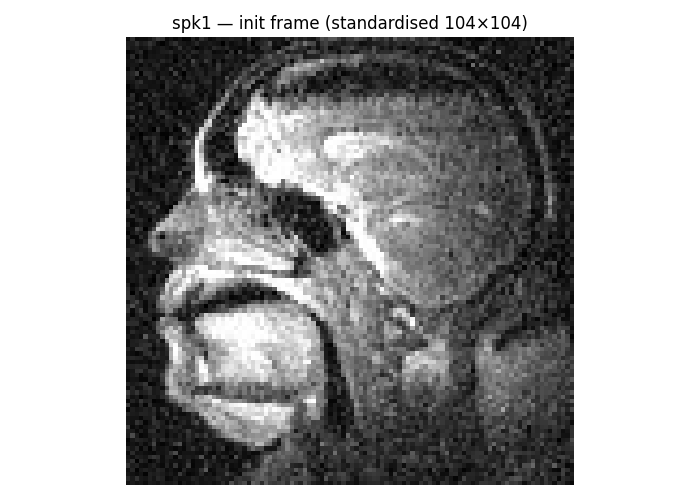

In [6]:
STANDARD_SIZE = 104  # all prompting is done on a 104×104 image

if not os.path.exists(INIT_FRAME_PATH):
    raise FileNotFoundError(
        f'Init frame not found: {INIT_FRAME_PATH}\nRun the frame-selection cell first.'
    )

_raw_image = Image.open(INIT_FRAME_PATH).convert('RGB')
print(f'Original image size: {_raw_image.size}')
image = np.array(_raw_image.resize((STANDARD_SIZE, STANDARD_SIZE), Image.LANCZOS))
img_predictor.set_image(image)
print(f'Image set: {image.shape}  (standardised to {STANDARD_SIZE}×{STANDARD_SIZE})')

fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(image, cmap='gray')
ax.set_title(f'{SPK} — init frame (standardised {STANDARD_SIZE}×{STANDARD_SIZE})')
ax.axis('off')
plt.tight_layout()
plt.show()

In [7]:
# ── Edit this list to match your segmentation targets ────────────────────
REGION_DEFS = [
    {'name': 'upper lip',  'color': '#3cb44b'},
    {'name': 'lower lip', 'color': '#e6194b'},
    {'name': 'tongue',      'color': '#4363d8'},
    {'name': 'palate_velum',  'color': '#f58231'},
    {'name': 'airway',      'color': '#911eb4'},
]
# ─────────────────────────────────────────────────────────────────────────

for i, rd in enumerate(REGION_DEFS):
    rd['obj_id'] = i

# point store: {region_name: {'points': [[x,y],...], 'labels': [1/0,...]}}
regions = {rd['name']: {'points': [], 'labels': []} for rd in REGION_DEFS}

print('Regions:')
for rd in REGION_DEFS:
    print(f"  [{rd['obj_id']}] {rd['name']}  {rd['color']}")

Regions:
  [0] upper lip  #3cb44b
  [1] lower lip  #e6194b
  [2] tongue  #4363d8
  [3] palate_velum  #f58231
  [4] airway  #911eb4


In [8]:
def show_mask(mask, ax, obj_id=None):
    cmap  = plt.get_cmap('tab10')
    cidx  = 0 if obj_id is None else obj_id % 10
    color = np.array([*cmap(cidx)[:3], 0.5])
    h, w  = mask.shape[-2:]
    ax.imshow(mask.reshape(h, w, 1) * color.reshape(1, 1, 4))

def show_points(coords, labels, ax, marker_size=200):
    pos = coords[labels == 1]
    neg = coords[labels == 0]
    ax.scatter(pos[:, 0], pos[:, 1], color='green', marker='*',
               s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg[:, 0], neg[:, 1], color='red', marker='*',
               s=marker_size, edgecolor='white', linewidth=1.25)

prompts = {}

## 3 — Prompt Regions (click-based)

1. Pick a **region** from the dropdown
2. Choose **Positive (+)** or **Negative (−)** mode with the toggle
3. **Click** anywhere on the canvas image to place a point — the mask overlay updates immediately
4. Use **Clear Region** to remove all points for the selected region
5. Switch regions and repeat until all targets are marked

No session found at /data1/span_data/gloss/spk1/sam_seg/sessions/session.json — starting fresh.


Image: 104×104 px


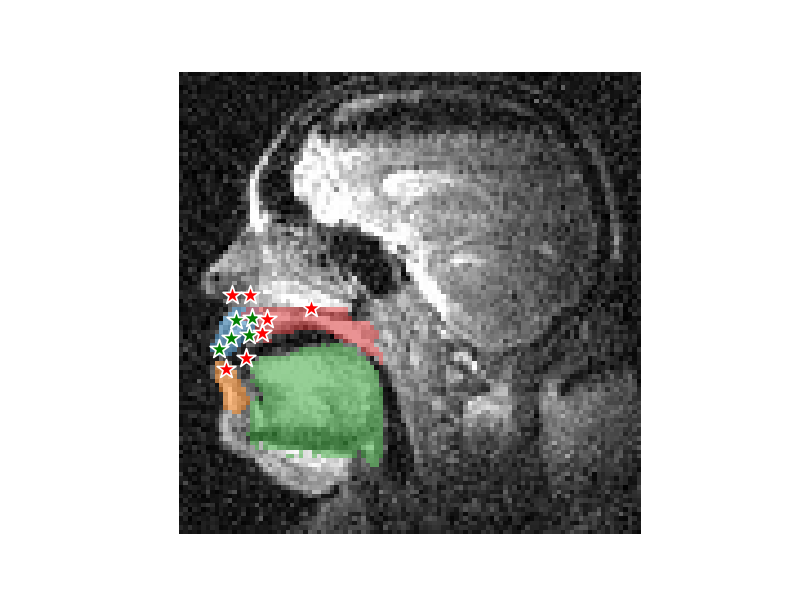

In [28]:
# ── set True to load existing prompts from session.json ──────────────────
LOAD_SESSION = True
# ─────────────────────────────────────────────────────────────────────────

if LOAD_SESSION:
    _sp = os.path.join(SAM_SEG_DIR, 'sessions', 'session.json')
    if os.path.exists(_sp):
        with open(_sp) as _f:
            _s = json.load(_f)
        for _r in _s['regions']:
            if _r['name'] in regions:
                regions[_r['name']]['points'] = _r['points']
                regions[_r['name']]['labels'] = _r['labels']
        print(f'Loaded session from {_sp}')
        for name, r in regions.items():
            print(f"  {name}: {len(r['points'])} point(s)")
    else:
        print(f'No session found at {_sp} — starting fresh.')

# ── interactive matplotlib figure ─────────────────────────────────────────
h_img, w_img = image.shape[:2]

fig, ax = plt.subplots(figsize=(8, 6))
fig.canvas.header_visible = False
fig.canvas.toolbar_visible = False
ax.set_title('Click to place points. Left=add, scroll/undo btn=remove last.')
ax.axis('off')

def _redraw():
    ax.clear()
    ax.imshow(image, cmap='gray')
    ax.axis('off')

    current_region = region_dd.value

    for rd in REGION_DEFS:
        r = regions[rd['name']]
        if not r['points']:
            continue
        pts = np.array(r['points'], dtype=np.float32)
        lbs = np.array(r['labels'], np.int32)
        try:
            masks, _, _ = img_predictor.predict(
                point_coords=pts, point_labels=lbs, multimask_output=False
            )
        except Exception:
            continue
        show_mask(masks[0], ax, obj_id=rd['obj_id'])
        # only show points for the currently selected region
        if rd['name'] == current_region:
            show_points(pts, lbs, ax, marker_size=dot_slider.value * 50)

    fig.canvas.draw_idle()

def _on_click(event):
    if event.inaxes != ax or event.xdata is None:
        return
    name = region_dd.value
    lbl  = 1 if mode_tog.value == 'Positive (+)' else 0
    regions[name]['points'].append([float(event.xdata), float(event.ydata)])
    regions[name]['labels'].append(lbl)
    n = len(regions[name]['points'])
    status_lbl.value = f'{name}: {n} point(s)'
    _redraw()

def on_undo(btn):
    name = region_dd.value
    r    = regions[name]
    if r['points']:
        r['points'].pop()
        r['labels'].pop()
        n = len(r['points'])
        status_lbl.value = f'{name}: {n} point(s) (undone)'
        _redraw()
    else:
        status_lbl.value = f'{name}: nothing to undo'

def on_clear(btn):
    name = region_dd.value
    regions[name]['points'].clear()
    regions[name]['labels'].clear()
    status_lbl.value = f'{name}: cleared'
    _redraw()

# ── widgets ───────────────────────────────────────────────────────────────
region_dd  = Dropdown(
    options=[rd['name'] for rd in REGION_DEFS],
    description='Region:',
    layout=widgets.Layout(width='260px'),
)
mode_tog   = ToggleButtons(
    options=['Positive (+)', 'Negative (−)'],
    value='Positive (+)',
    description='Mode:',
    button_style='',
)
dot_slider = widgets.IntSlider(
    value=4, min=1, max=20, step=1,
    description='Dot size:',
    continuous_update=False,
    layout=widgets.Layout(width='320px'),
)
undo_btn   = widgets.Button(description='Undo', button_style='info')
clear_btn  = widgets.Button(description='Clear Region', button_style='warning')
status_lbl = Label('Select mode and click on the image.')

fig.canvas.mpl_connect('button_press_event', _on_click)
undo_btn.on_click(on_undo)
clear_btn.on_click(on_clear)
dot_slider.observe(lambda _: _redraw(), names='value')
region_dd.observe(lambda _: _redraw(), names='value')

display(HBox([region_dd, mode_tog]))
display(HBox([dot_slider, undo_btn, clear_btn, status_lbl]))
print(f'Image: {w_img}×{h_img} px')
_redraw()

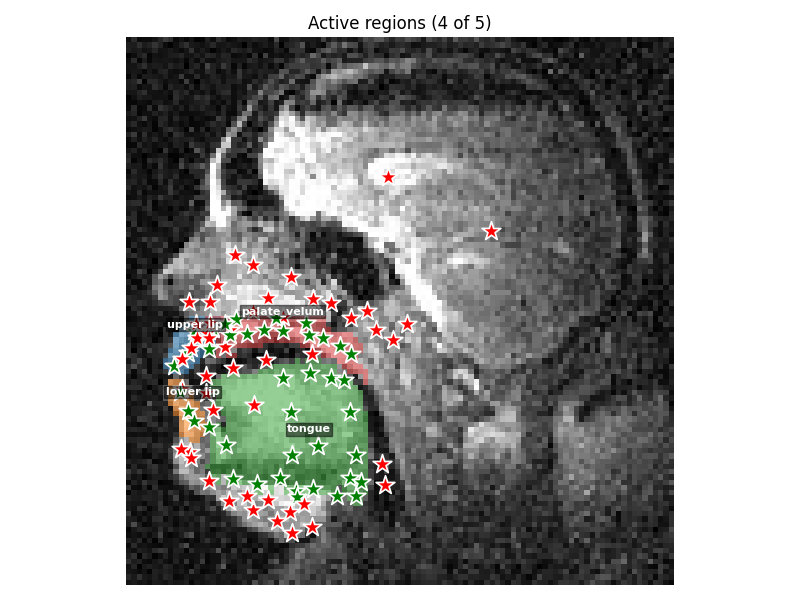


4 active region(s):
  [0] upper lip: 12 point(s)
  [1] lower lip: 10 point(s)
  [2] tongue: 36 point(s)
  [3] palate_velum: 34 point(s)


In [26]:
# ── diagnostic: show all active regions on the init frame ─────────────────
active = [rd for rd in REGION_DEFS if regions[rd['name']]['points']]

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(image, cmap='gray')
ax.set_title(f'Active regions ({len(active)} of {len(REGION_DEFS)})')
ax.axis('off')

for rd in active:
    r   = regions[rd['name']]
    pts = np.array(r['points'], dtype=np.float32)
    lbs = np.array(r['labels'], np.int32)
    masks, scores, _ = img_predictor.predict(
        point_coords=pts, point_labels=lbs, multimask_output=False,
    )
    show_mask(masks[0], ax, obj_id=rd['obj_id'])
    show_points(pts, lbs, ax, marker_size=200)
    # label the region
    cx, cy = pts[lbs == 1].mean(axis=0) if (lbs == 1).any() else pts.mean(axis=0)
    ax.text(cx, cy - 3, rd['name'], color='white', fontsize=8,
            ha='center', va='bottom', fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.5, pad=1))

plt.tight_layout()
plt.show()

print(f'\n{len(active)} active region(s):')
for rd in active:
    r = regions[rd['name']]
    print(f"  [{rd['obj_id']}] {rd['name']}: {len(r['points'])} point(s)")

## 3 — Alternative - Prompt Regions

Set `ann_obj_id`, `points`, and `labels` in the cell below and run it to preview the mask.  
**Duplicate the cell** for each region. `obj_id` must match the corresponding entry in `REGION_DEFS`.

In [ ]:
### REGION 1 ###

# ── Edit these for each region — duplicate this cell per region ──────────
ann_obj_id = 0
points     = np.array([[45, 55], [32, 65], [53, 76], [50, 82]], dtype=np.float32)
labels     = np.array([1, 1, 1,0], np.int32)   # 1=positive, 0=negative
# ─────────────────────────────────────────────────────────────────────────

prompts[ann_obj_id] = points, labels

masks, scores, _ = img_predictor.predict(
    point_coords=points,
    point_labels=labels,
    multimask_output=False,
)

# store in regions dict for export
_rd = next((r for r in REGION_DEFS if r['obj_id'] == ann_obj_id), None)
if _rd:
    regions[_rd['name']]['points'] = points.tolist()
    regions[_rd['name']]['labels'] = labels.tolist()

plt.figure(figsize=(9, 6))
plt.title(f"{_rd['name'] if _rd else ann_obj_id}  |  score={scores[0]:.3f}")
plt.imshow(image, cmap='gray')
show_points(points, labels, plt.gca())
show_mask(masks[0], plt.gca(), obj_id=ann_obj_id)
#plt.axis('off')
plt.tight_layout()
plt.show()

## 4 — Test Propagation

Randomly samples 200 consecutive frames from the speaker's videos, propagates the prompts defined above, and plays the overlay video inline.

In [27]:
import subprocess

N_SAMPLE    = 200                                                                                                                                         
MASK_OPACITY = 0.6  # 0.0 = invisible, 1.0 = fully opaque
                                                                                                                                                        
# ── load points from session.json if it exists ───────────────────────────                                                                               
_session_path = os.path.join(SAM_SEG_DIR, 'session.json')
if os.path.exists(_session_path):                                                                                                                         
    with open(_session_path) as _f:                                                                                                                     
        _session = json.load(_f)
    for _r in _session['regions']:                                                                                                                        
        if _r['name'] in regions:
            regions[_r['name']]['points'] = _r['points']                                                                                                  
            regions[_r['name']]['labels'] = _r['labels']                                                                                                
    print(f'Loaded points from {_session_path}')                                                                                                          

active = [rd for rd in REGION_DEFS if regions[rd['name']]['points']]                                                                                      
if not active:                                                                                                                                          
    raise RuntimeError('No regions have points yet. Complete the prompting cells first.')
print(active)                                                                                                                                             

# ── pick a random video + frame window ──────────────────────────────────                                                                                
test_vid  = random.choice(video_files)                                                                                                                  
test_path = os.path.join(VIDEO_DIR, test_vid)
                                                                                                                                                        
_tc = cv2.VideoCapture(test_path)
n_total = int(_tc.get(cv2.CAP_PROP_FRAME_COUNT))                                                                                                          
h_vid   = int(_tc.get(cv2.CAP_PROP_FRAME_HEIGHT))                                                                                                       
w_vid   = int(_tc.get(cv2.CAP_PROP_FRAME_WIDTH))                                                                                                          
_tc.release()
                                                                                                                                                        
# use ffprobe for reliable FPS (cv2 returns 0 for many AVI files)                                                                                       
_fps_result = subprocess.run(
    ['ffprobe', '-v', 'error', '-select_streams', 'v:0',                                                                                                  
    '-show_entries', 'stream=r_frame_rate',
    '-of', 'default=noprint_wrappers=1:nokey=1', test_path],                                                                                             
    capture_output=True, text=True,                                                                                                                       
)
try:                                                                                                                                                      
    _n, _d = _fps_result.stdout.strip().split('/')                                                                                                      
    fps_vid = float(_n) / float(_d)
except Exception:
    fps_vid = cv2.VideoCapture(test_path).get(cv2.CAP_PROP_FPS) or 25.0                                                                                   

n_sample  = min(N_SAMPLE, n_total)                                                                                                                        
start_idx = random.randint(0, max(0, n_total - n_sample))                                                                                               
end_idx   = start_idx + n_sample                                                                                                                          

print(f'Video   : {test_vid}  ({n_total} frames @ {fps_vid:.1f} fps)')                                                                                    
print(f'Window  : frames {start_idx}-{end_idx - 1}  ({n_sample} frames)')                                                                               
                                                                                                                                                        
# ── extract frames, prepending the saved init frame as frame 0 ───────────
_tmp = tempfile.mkdtemp(prefix='sam2_test_')                                                                                                              
                                                                                                                                                        
_frame_offset = 0
if os.path.exists(INIT_FRAME_PATH):                                                                                                                       
    _init_img = Image.open(INIT_FRAME_PATH).convert('RGB').resize(
        (STANDARD_SIZE, STANDARD_SIZE), Image.LANCZOS)
    _init_img.save(os.path.join(_tmp, '00000.jpg'), 'JPEG', quality=95)
    _frame_offset = 1
    print(f'Prepended init frame as anchor (00000.jpg, {STANDARD_SIZE}×{STANDARD_SIZE})')                                                                                                  

_tc2 = cv2.VideoCapture(test_path)                                                                                                                        
_tc2.set(cv2.CAP_PROP_POS_FRAMES, start_idx)                                                                                                            
for i in range(n_sample):
    ret, frm = _tc2.read()                                                                                                                                
    if not ret:
        break
    frm = cv2.resize(frm, (STANDARD_SIZE, STANDARD_SIZE), interpolation=cv2.INTER_LANCZOS4)
    cv2.imwrite(os.path.join(_tmp, f'{i + _frame_offset:05d}.jpg'), frm,                                                                                
                [cv2.IMWRITE_JPEG_QUALITY, 95])                                                                                                           
_tc2.release()
print(f'Frames extracted to {_tmp}')                                                                                                                      
                                                                                                                                                        
# ── SAM2 propagation ─────────────────────────────────────────────────────                                                                               
state = vid_predictor.init_state(
    video_path=_tmp, offload_video_to_cpu=True, offload_state_to_cpu=False,                                                                               
)                                                                                                                                                       
vid_predictor.reset_state(state)

for rd in active:                                                                                                                                         
    r = regions[rd['name']]
    vid_predictor.add_new_points_or_box(                                                                                                                  
        state, frame_idx=0, obj_id=rd['obj_id'],                                                                                                        
        points=np.array(r['points'], dtype=np.float32),
        labels=np.array(r['labels'],  np.int32),                                                                                                          
        clear_old_points=True,
    )                                                                                                                                                     
                                                                                                                                                        
print('Propagating...')
segs = {}
for fid, oids, logits in vid_predictor.propagate_in_video(state):
    video_fid = fid - _frame_offset                                                                                                                       
    if video_fid >= 0:
        segs[video_fid] = {oid: (logits[i] > 0).cpu().numpy() for i, oid in enumerate(oids)}                                                              
print(f'Done — {len(segs)} frames segmented.')                                                                                                            

# ── render overlay (mp4v scratch file) ───────────────────────────────────                                                                               
def _hex_bgr(h):                                                                                                                                        
    h = h.lstrip('#')
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)                                                                                           
    return np.array([b, g, r], dtype=np.float32)
                                                                                                                                                        
_raw_path = os.path.join(SAM_SEG_DIR, f'{SPK}_test_prop_raw.mp4')                                                                                       
_writer = cv2.VideoWriter(_raw_path, cv2.VideoWriter_fourcc(*'mp4v'), fps_vid, (w_vid, h_vid))                                                            
_tc3 = cv2.VideoCapture(test_path)                                                                                                                        
_tc3.set(cv2.CAP_PROP_POS_FRAMES, start_idx)
                                                                                                                                                        
for i in range(n_sample):                                                                                                                                 
    ret, frm = _tc3.read()
    if not ret:                                                                                                                                           
        break                                                                                                                                           
    canvas = frm.astype(np.float32)
    if i in segs:
        for rd in active:
            mask = segs[i].get(rd['obj_id'])
            if mask is None:                                                                                                                              
                continue
            m = np.squeeze(mask).astype(bool)
            if m.shape != (h_vid, w_vid):
                m = cv2.resize(m.astype(np.uint8), (w_vid, h_vid),
                               interpolation=cv2.INTER_NEAREST).astype(bool)                                                                                                             
            canvas[m] = (1 - MASK_OPACITY) * canvas[m] + MASK_OPACITY * _hex_bgr(rd['color'])
    _writer.write(canvas.astype(np.uint8))                                                                                                                

_tc3.release()                                                                                                                                            
_writer.release()                                                                                                                                       
shutil.rmtree(_tmp)
                                                                                                                                                        
# ── re-encode to H.264 so the browser can play it ────────────────────────
overlay_path = os.path.join(SAM_SEG_DIR, f'{SPK}_test_prop.mp4')                                                                                          
subprocess.run(                                                                                                                                         
    ['ffmpeg', '-y', '-i', _raw_path,                                                                                                                     
    '-vcodec', 'libx264', '-pix_fmt', 'yuv420p', '-crf', '23',
    overlay_path],                                                                                                                                       
    check=True, capture_output=True,                                                                                                                    
)                                                                                                                                                         
os.remove(_raw_path)
print(f'Overlay saved to {overlay_path}')                                                                                                                 
                                                                                                                                                        
display(Video(overlay_path, embed=True, width=700))

[{'name': 'upper lip', 'color': '#3cb44b', 'obj_id': 0}, {'name': 'lower lip', 'color': '#e6194b', 'obj_id': 1}, {'name': 'tongue', 'color': '#4363d8', 'obj_id': 2}, {'name': 'palate_velum', 'color': '#f58231', 'obj_id': 3}]
Video   : spk1_pre_caterpillar2_2.avi  (4241 frames @ 99.4 fps)
Window  : frames 3472-3671  (200 frames)
Prepended init frame as anchor (00000.jpg, 104×104)
Frames extracted to /tmp/sam2_test_owvhfllz


frame loading (JPEG): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:03<00:00, 59.20it/s]


Propagating...


propagate in video: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 201/201 [00:43<00:00,  4.62it/s]


Done — 200 frames segmented.
Overlay saved to /data1/span_data/gloss/spk1/sam_seg/spk1_test_prop.mp4


## 5 — Export Session JSON

Saves all region prompts and the init-frame index to `sam_seg/session.json`.  
This file is consumed by `sam2_propagate.py`.

In [12]:
active = [rd for rd in REGION_DEFS if regions[rd['name']]['points']]
if not active:
    raise RuntimeError('No prompts found. Complete the prompting cell first.')

session = {
    'speaker':           SPK,
    'init_frame_path':   INIT_FRAME_PATH,
    'standard_size':     STANDARD_SIZE,
    'regions': [
        {
            'name':   rd['name'],
            'obj_id': rd['obj_id'],
            'color':  rd['color'],
            'points': regions[rd['name']]['points'],
            'labels': regions[rd['name']]['labels'],
        }
        for rd in active
    ],
}

sessions_dir = os.path.join(SAM_SEG_DIR, 'sessions')
os.makedirs(sessions_dir, exist_ok=True)
session_path = os.path.join(sessions_dir, 'session1.json')
with open(session_path, 'w') as f:
    json.dump(session, f, indent=2)

print(f'Session saved to {session_path}')
print()
print(json.dumps(session, indent=2))
print()
print(f'To propagate across all videos run:')
print(f'  python sam2_propagate.py --spk {SPK}')

Session saved to /data1/span_data/usc_lss/sam_seg/sessions/session1.json

{
  "speaker": "",
  "init_frame_path": "/data1/span_data/usc_lss/sam_seg/_frame.jpg",
  "standard_size": 104,
  "regions": [
    {
      "name": "lower",
      "obj_id": 0,
      "color": "#3cb44b",
      "points": [
        [
          38.443722943722946,
          60.95454545454545
        ],
        [
          22.235930735930737,
          58.92857142857143
        ],
        [
          29.214285714285722,
          56.9025974025974
        ],
        [
          43.396103896103895,
          53.75108225108225
        ],
        [
          49.69913419913421,
          65.9069264069264
        ],
        [
          46.32251082251082,
          81.21428571428572
        ],
        [
          33.71645021645023,
          75.36147186147187
        ],
        [
          44.52164502164503,
          73.78571428571428
        ],
        [
          51.5,
          79.86363636363637
        ],
        [
       